# Task 7: Multi-Algorithm Recommendation System Comparison

## Objective
Build an E-commerce Recommendation System using multiple machine learning algorithms:
- Ridge Regression (Predict Average Rating)
- Logistic Regression (Predict Discount Applied)
- K-Means Clustering (Customer Segmentation)

## Dataset
E-commerce Customer Behavior Dataset

## Algorithms Used
- Ridge Regression
- Logistic Regression
- K-Means Clustering
- GridSearchCV

## Libraries
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


Load Dataset

In [2]:
# Load Dataset

df = pd.read_csv("E-commerce Customer Behavior - Sheet1.csv")

print("Dataset Loaded Successfully!\n")

# Display first 5 rows
df.head()

Dataset Loaded Successfully!



,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


Basic Information About Dataset

In [3]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset:
(350, 11)

Column Names:
['Customer ID', 'Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']

Data Types:
Customer ID                   int64
Gender                          str
Age                           int64
City                            str
Membership Type                 str
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase      int64
Satisfaction Level              str
dtype: object

Missing Values:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype

Exploratory Data Analysis - EDA

In [4]:
# Statistical Summary

df.describe(include='all')

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
count,350.000000,350,350.000000,350,350,350.000000,350.000000,350.000000,350,350.000000,348
unique,NaN,2,NaN,6,3,NaN,NaN,NaN,2,NaN,3
top,NaN,Female,NaN,New York,Gold,NaN,NaN,NaN,True,NaN,Satisfied
freq,NaN,175,NaN,59,117,NaN,NaN,NaN,175,NaN,125
mean,275.500000,NaN,33.597143,NaN,NaN,845.381714,12.600000,4.019143,NaN,26.588571,NaN
std,101.180532,NaN,4.870882,NaN,NaN,362.058695,4.155984,0.580539,NaN,13.440813,NaN
min,101.000000,NaN,26.000000,NaN,NaN,410.800000,7.000000,3.000000,NaN,9.000000,NaN
25%,188.250000,NaN,30.000000,NaN,NaN,502.000000,9.000000,3.500000,NaN,15.000000,NaN
50%,275.500000,NaN,32.500000,NaN,NaN,775.200000,12.000000,4.100000,NaN,23.000000,NaN
75%,362.750000,NaN,37.000000,NaN,NaN,1160.600000,15.000000,4.500000,NaN,38.000000,NaN


Visualize Numerical Features

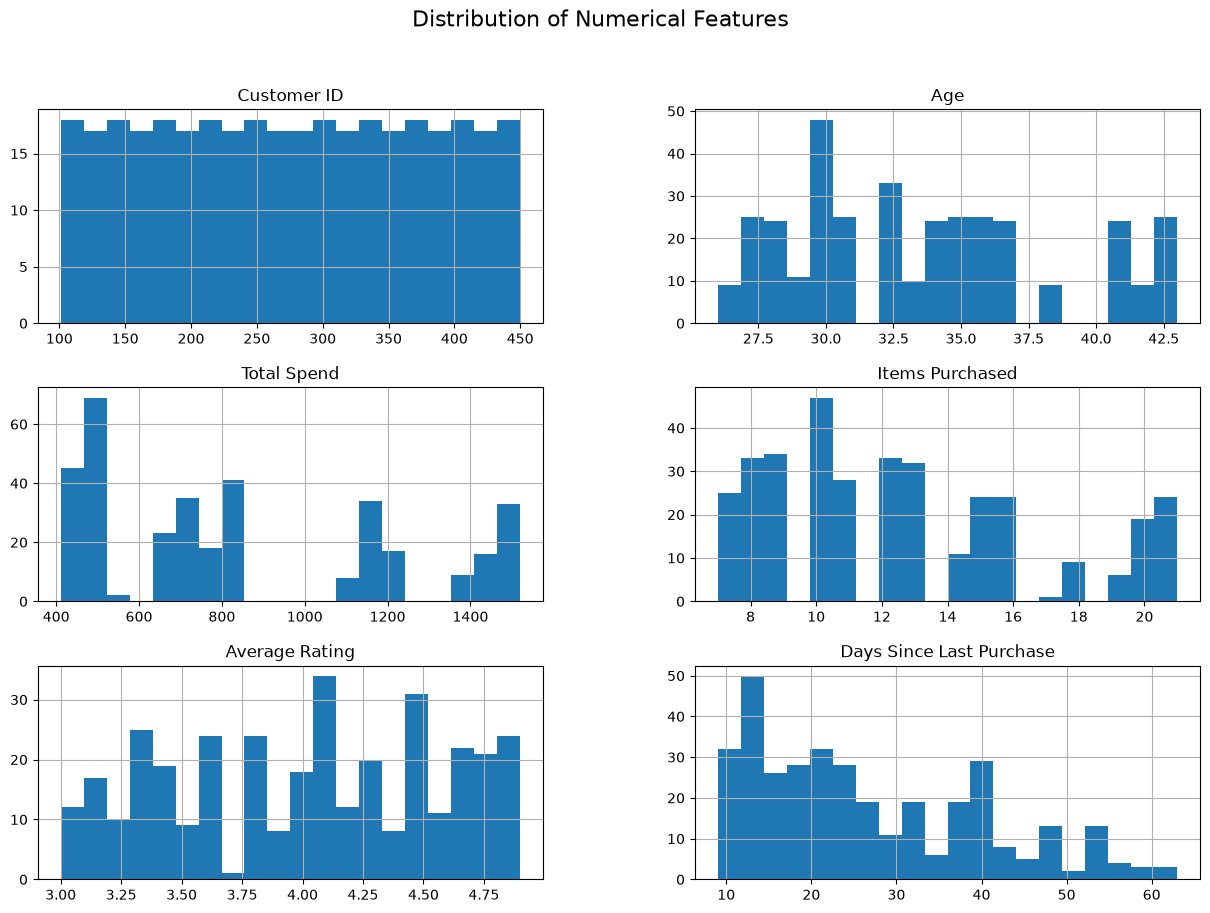

In [5]:
# Histograms for numerical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(15,10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.show()

Data Preprocessing

In [6]:
# Check missing values

print("Missing Values:\n")
print(df.isnull().sum())

# Remove duplicate rows

df.drop_duplicates(inplace=True)

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

Missing Values:

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

Dataset Shape After Removing Duplicates:
(350, 11)


Label Encoding

In [7]:
# Encode categorical columns

label_encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'City',
    'Membership Type',
    'Discount Applied',
    'Satisfaction Level'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("Categorical Columns Encoded Successfully!\n")

df.head()

Categorical Columns Encoded Successfully!



,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,0,29,4,1,1120.20,14,4.6,1,25,1
1,102,1,34,2,2,780.50,11,4.1,0,18,0
2,103,0,43,0,0,510.75,9,3.4,1,42,2
3,104,1,30,5,1,1480.30,19,4.7,0,12,1
4,105,1,27,3,2,720.40,13,4.0,1,55,2


 Feature Selection & Train-Test Split (Regression)

In [8]:
# Features for Regression

X_reg = df.drop(['Average Rating', 'Customer ID'], axis=1)

y_reg = df['Average Rating']

# Train-Test Split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train_reg.shape)
print("Testing Shape :", X_test_reg.shape)

Training Shape : (280, 9)
Testing Shape : (70, 9)


Feature Scaling

In [9]:
# Standardize Features

scaler = StandardScaler()

X_train_reg = scaler.fit_transform(X_train_reg)

X_test_reg = scaler.transform(X_test_reg)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


Ridge Regression Model

In [10]:
# Ridge Regression

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_reg, y_train_reg)

# Prediction

y_pred = ridge.predict(X_test_reg)

# Evaluation

mae = mean_absolute_error(y_test_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
r2 = r2_score(y_test_reg, y_pred)

print("Ridge Regression Results")
print("-"*40)

print("MAE :", round(mae,3))
print("RMSE :", round(rmse,3))
print("R2 Score :", round(r2,3))

Ridge Regression Results
----------------------------------------
MAE : 0.101
RMSE : 0.126
R2 Score : 0.951


Hyperparameter Tuning (Ridge Regression using GridSearchCV)

In [11]:
# Hyperparameter Tuning for Ridge Regression

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(X_train_reg, y_train_reg)

print("Best Alpha:", grid_ridge.best_params_)
print("Best Cross Validation Score:", round(grid_ridge.best_score_, 3))

Best Alpha: {'alpha': 0.01}
Best Cross Validation Score: 0.956


Evaluate Tuned Ridge Regression

In [12]:
# Best Ridge Model

best_ridge = grid_ridge.best_estimator_

y_pred_best = best_ridge.predict(X_test_reg)

mae_best = mean_absolute_error(y_test_reg, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_reg, y_pred_best))
r2_best = r2_score(y_test_reg, y_pred_best)

print("Tuned Ridge Regression Performance")
print("-"*45)

print("MAE :", round(mae_best,3))
print("RMSE :", round(rmse_best,3))
print("R² Score :", round(r2_best,3))

Tuned Ridge Regression Performance
---------------------------------------------
MAE : 0.102
RMSE : 0.131
R² Score : 0.947


Prepare Data for Logistic Regression

In [13]:
# Features and Target for Classification

X_cls = df.drop(['Discount Applied', 'Customer ID'], axis=1)

y_cls = df['Discount Applied']

# Train-Test Split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42
)

# Feature Scaling

scaler_cls = StandardScaler()

X_train_cls = scaler_cls.fit_transform(X_train_cls)
X_test_cls = scaler_cls.transform(X_test_cls)

print("Classification Data Ready!")

Classification Data Ready!


Logistic Regression Model

In [14]:
# Logistic Regression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_cls, y_train_cls)

# Prediction

y_pred_cls = log_model.predict(X_test_cls)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


Evaluate Logistic Regression

In [15]:
# Evaluation Metrics

accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)

print("Logistic Regression Results")
print("-"*45)

print("Accuracy :", round(accuracy,3))
print("Precision :", round(precision,3))
print("Recall :", round(recall,3))
print("F1 Score :", round(f1,3))

print("\nClassification Report\n")
print(classification_report(y_test_cls, y_pred_cls))

Logistic Regression Results
---------------------------------------------
Accuracy : 0.986
Precision : 1.0
Recall : 0.968
F1 Score : 0.984

Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       1.00      0.97      0.98        31

    accuracy                           0.99        70
   macro avg       0.99      0.98      0.99        70
weighted avg       0.99      0.99      0.99        70



Confusion Matrix Visualization

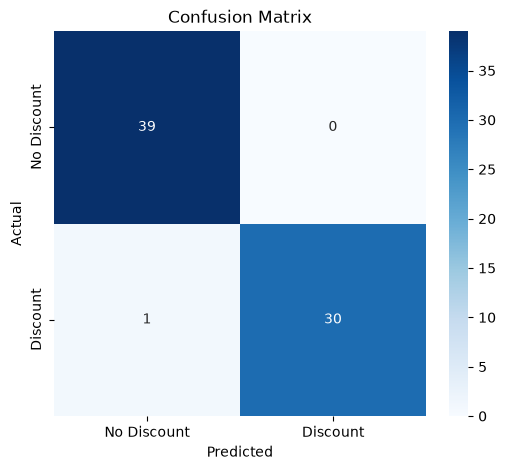

In [16]:
# Confusion Matrix

cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Discount', 'Discount'],
    yticklabels=['No Discount', 'Discount']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Hyperparameter Tuning for Logistic Regression

In [17]:
# GridSearchCV for Logistic Regression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

grid_log = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_log.fit(X_train_cls, y_train_cls)

print("Best Parameters:")
print(grid_log.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(grid_log.best_score_,3))

Best Parameters:
{'C': 10, 'max_iter': 100, 'solver': 'liblinear'}

Best Cross Validation Accuracy:
0.996


Evaluate Best Logistic Regression Model

In [18]:
# Best Logistic Regression Model

best_log_model = grid_log.best_estimator_

y_best_pred = best_log_model.predict(X_test_cls)

print("Accuracy :", round(accuracy_score(y_test_cls, y_best_pred),3))
print("Precision :", round(precision_score(y_test_cls, y_best_pred),3))
print("Recall :", round(recall_score(y_test_cls, y_best_pred),3))
print("F1 Score :", round(f1_score(y_test_cls, y_best_pred),3))

print("\nClassification Report\n")
print(classification_report(y_test_cls, y_best_pred))

Accuracy : 0.986
Precision : 1.0
Recall : 0.968
F1 Score : 0.984

Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       1.00      0.97      0.98        31

    accuracy                           0.99        70
   macro avg       0.99      0.98      0.99        70
weighted avg       0.99      0.99      0.99        70



Prepare Data for K-Means Clustering

In [19]:
# Features for Customer Segmentation

cluster_features = df[
    [
        'Age',
        'Total Spend',
        'Items Purchased',
        'Average Rating',
        'Days Since Last Purchase'
    ]
]

# Scale Features

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_features)

print("Data Prepared for K-Means Clustering!")

Data Prepared for K-Means Clustering!


Elbow Method

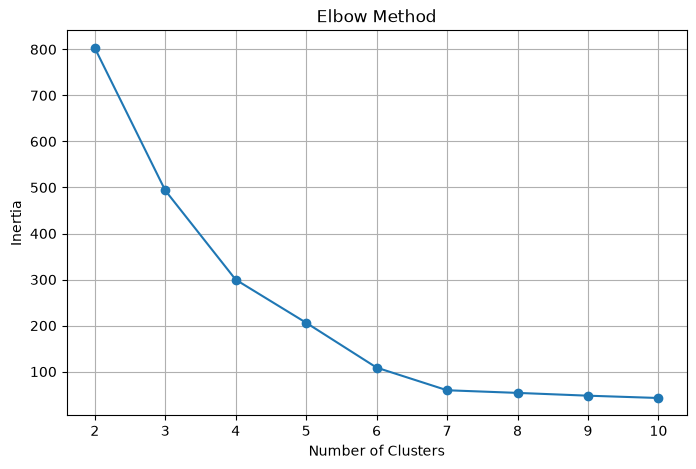

In [20]:
# Elbow Method

inertia = []

k_values = range(2,11)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(cluster_scaled)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

Train K-Means Model & Calculate Silhouette Score

In [21]:
# Train K-Means Model

optimal_clusters = 3

kmeans = KMeans(
    n_clusters=optimal_clusters,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

# Add Cluster Labels

df['Cluster'] = clusters

# Evaluation

silhouette = silhouette_score(cluster_scaled, clusters)

print("K-Means Clustering Results")
print("-"*40)

print("Number of Clusters :", optimal_clusters)
print("Inertia :", round(kmeans.inertia_,2))
print("Silhouette Score :", round(silhouette,3))

K-Means Clustering Results
----------------------------------------
Number of Clusters : 3
Inertia : 493.58
Silhouette Score : 0.494


Visualize Customer Segments

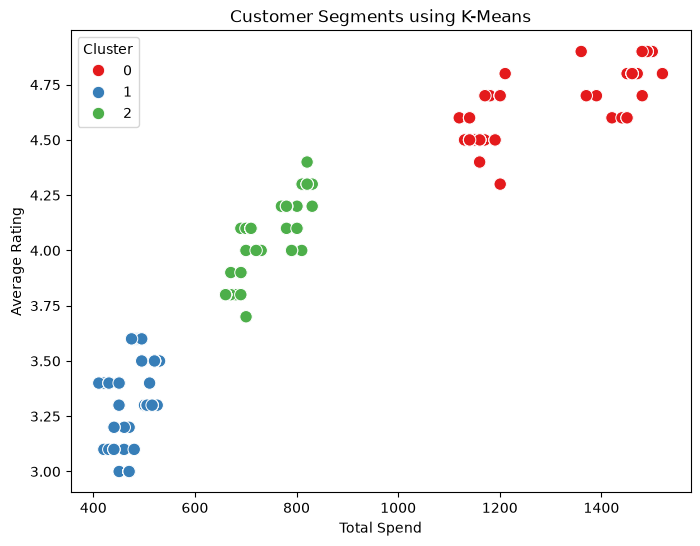

In [22]:
# Customer Segments

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Total Spend',
    y='Average Rating',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=80
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Total Spend")
plt.ylabel("Average Rating")

plt.show()

Model Comparison Table

In [23]:
# Model Comparison

comparison = pd.DataFrame({
    "ML Task":[
        "Regression",
        "Classification",
        "Clustering"
    ],
    
    "Algorithm":[
        "Ridge Regression",
        "Logistic Regression",
        "K-Means"
    ],
    
    "Target":[
        "Average Rating",
        "Discount Applied",
        "Customer Segments"
    ],
    
    "Evaluation":[
        f"MAE={mae_best:.3f}, RMSE={rmse_best:.3f}, R²={r2_best:.3f}",
        f"Accuracy={accuracy_score(y_test_cls,y_best_pred):.3f}, F1={f1_score(y_test_cls,y_best_pred):.3f}",
        f"Silhouette={silhouette:.3f}"
    ]
})

comparison

,ML Task,Algorithm,Target,Evaluation
0,Regression,Ridge Regression,Average Rating,"MAE=0.102, RMSE=0.131, R²=0.947"
1,Classification,Logistic Regression,Discount Applied,"Accuracy=0.986, F1=0.984"
2,Clustering,K-Means,Customer Segments,Silhouette=0.494


Business Interpretation

In [24]:
print("="*70)
print("BUSINESS INTERPRETATION")
print("="*70)

print("""
1. Ridge Regression predicts customer ratings effectively.
   This helps recommend products that customers are likely to rate highly.

2. Logistic Regression predicts whether a discount is applied,
   enabling targeted promotional strategies.

3. K-Means Clustering segments customers based on purchasing behavior,
   allowing personalized marketing campaigns.

4. GridSearchCV improves the performance of both regression and
   classification models by selecting optimal hyperparameters.

5. Customer segmentation helps identify different shopping patterns,
   such as high-value customers and occasional buyers.
""")

BUSINESS INTERPRETATION

1. Ridge Regression predicts customer ratings effectively.
   This helps recommend products that customers are likely to rate highly.

2. Logistic Regression predicts whether a discount is applied,
   enabling targeted promotional strategies.

3. K-Means Clustering segments customers based on purchasing behavior,
   allowing personalized marketing campaigns.

4. GridSearchCV improves the performance of both regression and
   classification models by selecting optimal hyperparameters.

5. Customer segmentation helps identify different shopping patterns,
   such as high-value customers and occasional buyers.



Final Conclusion

In [25]:
print("="*70)
print("FINAL CONCLUSION")
print("="*70)

print("""
✔ Successfully loaded and preprocessed the E-commerce dataset.

✔ Built a Ridge Regression model to predict Average Rating.

✔ Built a Logistic Regression model to predict Discount Applied.

✔ Used GridSearchCV for hyperparameter tuning.

✔ Applied K-Means Clustering for customer segmentation.

✔ Evaluated all models using suitable metrics.

✔ Compared multiple machine learning algorithms.

✔ Demonstrated how different ML techniques support business decision-making
   in an E-commerce recommendation system.
""")

FINAL CONCLUSION

✔ Successfully loaded and preprocessed the E-commerce dataset.

✔ Built a Ridge Regression model to predict Average Rating.

✔ Built a Logistic Regression model to predict Discount Applied.

✔ Used GridSearchCV for hyperparameter tuning.

✔ Applied K-Means Clustering for customer segmentation.

✔ Evaluated all models using suitable metrics.

✔ Compared multiple machine learning algorithms.

✔ Demonstrated how different ML techniques support business decision-making
   in an E-commerce recommendation system.

